In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
layoffs = pd.read_csv('../data/cleaned/layoffs_clean.csv')
placement = pd.read_csv('../data/cleaned/placement_clean.csv')
hr = pd.read_csv('../data/cleaned/hr_clean.csv')

# Convert date
layoffs['date'] = pd.to_datetime(layoffs['date'])
layoffs['year'] = layoffs['date'].dt.year
layoffs['month'] = layoffs['date'].dt.month

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Data loaded successfully!")

✅ Data loaded successfully!


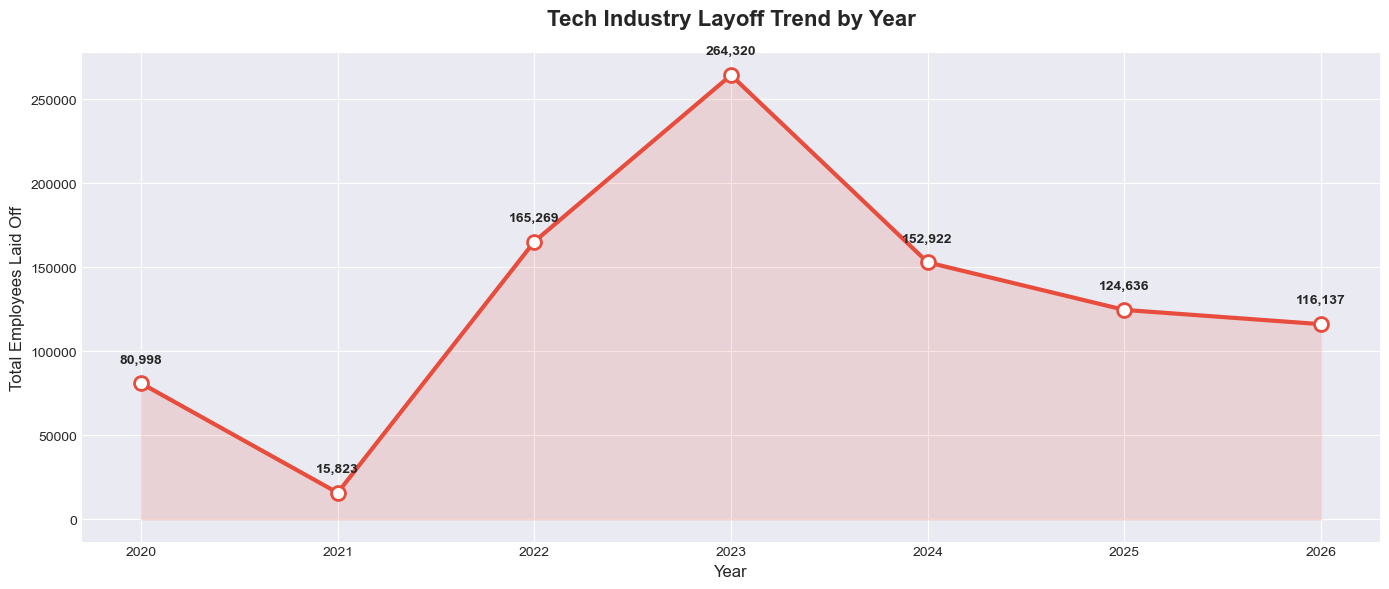

✅ Chart 7 saved!


In [2]:
plt.figure(figsize=(14, 6))

yearly = layoffs.groupby('year')['total_laid_off'].sum().reset_index()
yearly = yearly[yearly['total_laid_off'] > 0]

plt.plot(yearly['year'], yearly['total_laid_off'],
         marker='o', linewidth=3,
         markersize=10, color='#e74c3c',
         markerfacecolor='white',
         markeredgewidth=2)

# Fill area under line
plt.fill_between(yearly['year'],
                 yearly['total_laid_off'],
                 alpha=0.15, color='#e74c3c')

# Add value labels
for x, y in zip(yearly['year'], yearly['total_laid_off']):
    plt.annotate(f'{int(y):,}',
                xy=(x, y),
                xytext=(0, 15),
                textcoords='offset points',
                ha='center', fontsize=10,
                fontweight='bold')

plt.title('Tech Industry Layoff Trend by Year',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Employees Laid Off', fontsize=12)
plt.xticks(yearly['year'])
plt.tight_layout()
plt.savefig('../data/charts/chart7_yearly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

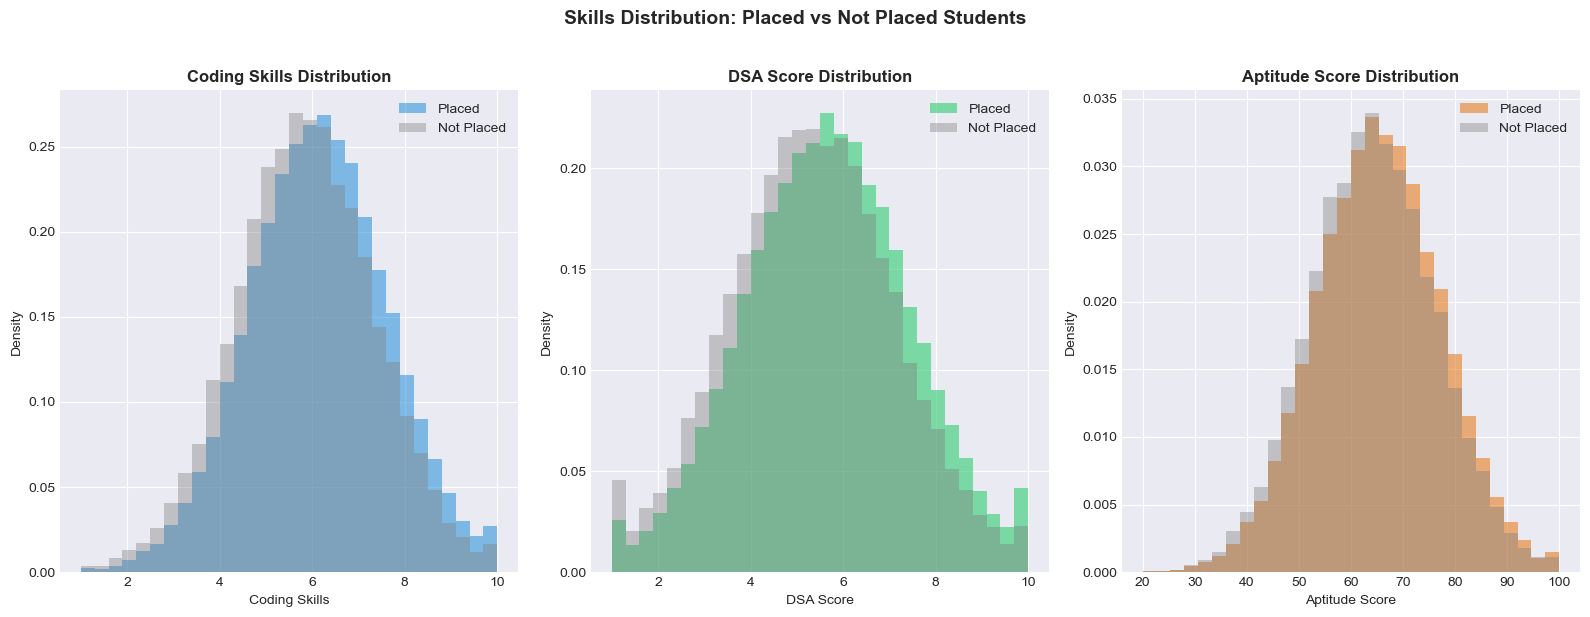

✅ Chart 8 saved!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

skills = ['coding_skills', 'dsa_score', 'aptitude_score']
titles = ['Coding Skills', 'DSA Score', 'Aptitude Score']
colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, skill, title, color in zip(axes, skills, titles, colors):
    placed = placement[placement['placement_status']==1][skill]
    not_placed = placement[placement['placement_status']==0][skill]

    ax.hist(placed, alpha=0.6, bins=30,
            color=color, label='Placed', density=True)
    ax.hist(not_placed, alpha=0.4, bins=30,
            color='gray', label='Not Placed', density=True)

    ax.set_title(f'{title} Distribution',
                fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Skills Distribution: Placed vs Not Placed Students',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/charts/chart8_skills_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

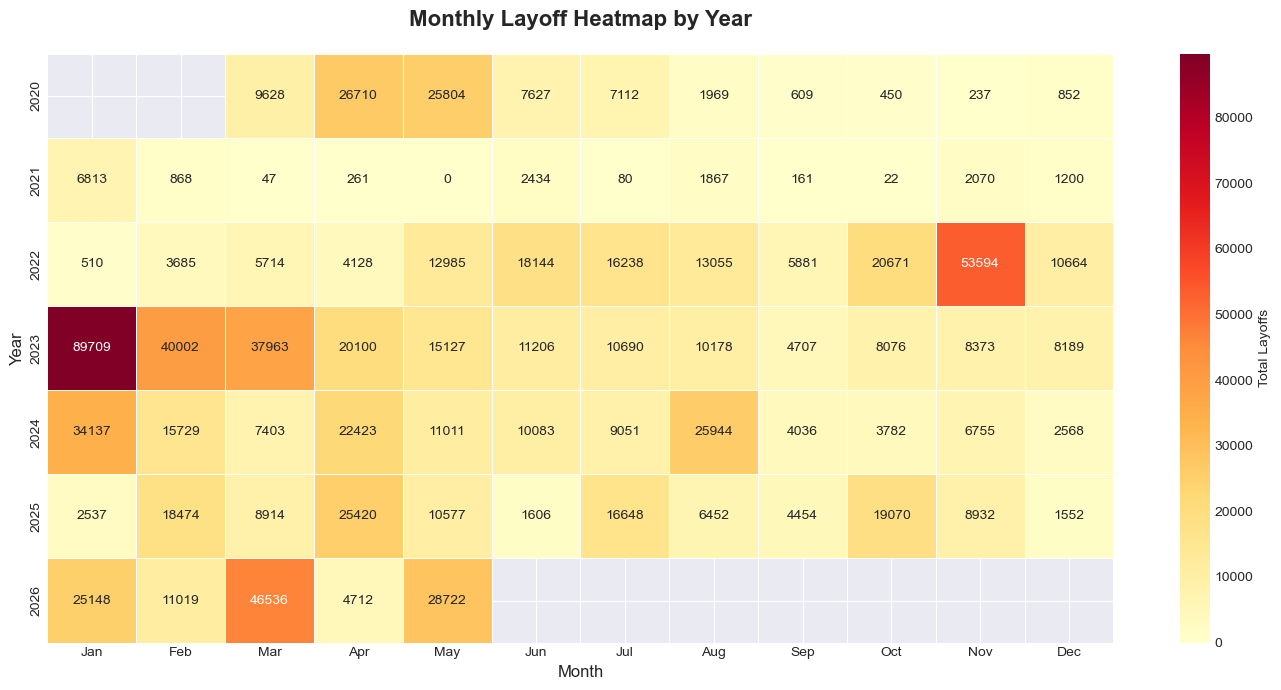

✅ Chart 9 saved!


In [4]:
plt.figure(figsize=(14, 7))

# Create pivot table
monthly = layoffs.groupby(['year', 'month'])['total_laid_off'].sum().reset_index()
pivot = monthly.pivot(index='year', columns='month', values='total_laid_off')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Total Layoffs'})

plt.title('Monthly Layoff Heatmap by Year',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('../data/charts/chart9_monthly_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

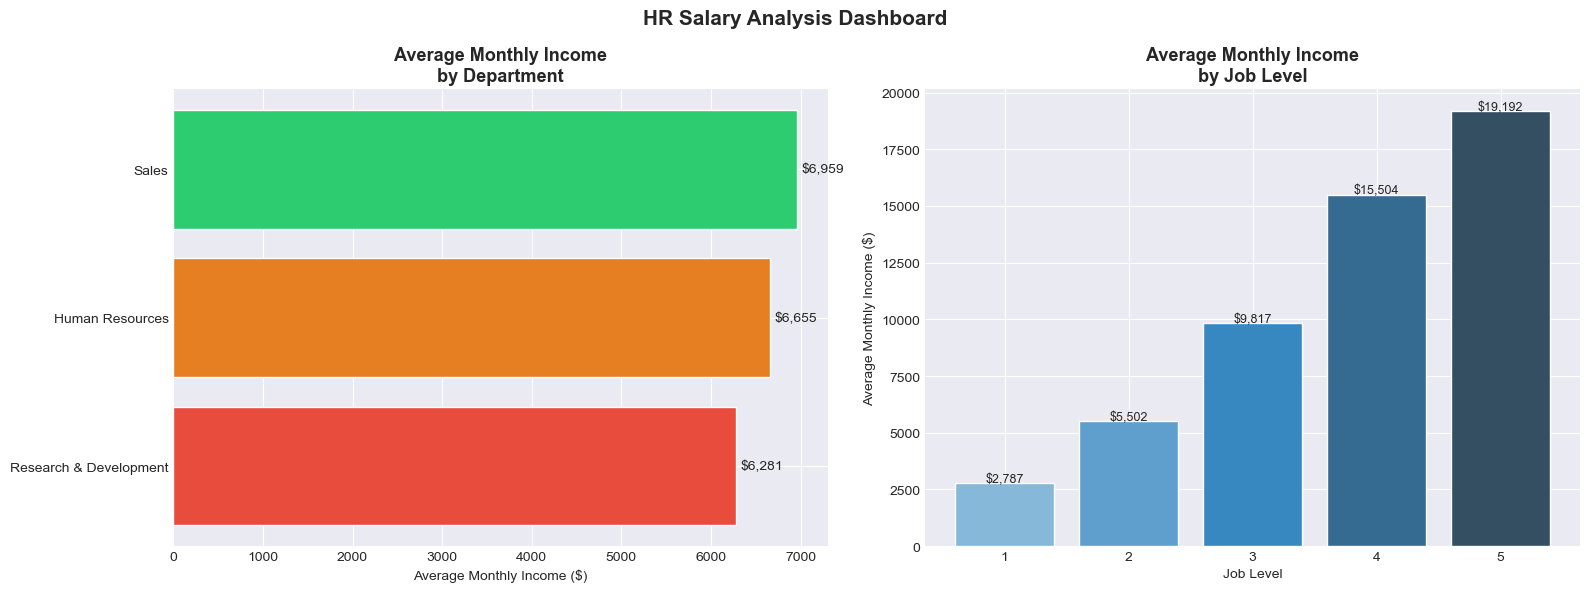

✅ Chart 10 saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart — Salary by Department
dept_salary = hr.groupby('Department')['MonthlyIncome'].mean().sort_values()
colors = ['#e74c3c', '#e67e22', '#2ecc71']
axes[0].barh(dept_salary.index, dept_salary.values,
             color=colors, edgecolor='white')
axes[0].set_title('Average Monthly Income\nby Department',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Monthly Income ($)')
for i, v in enumerate(dept_salary.values):
    axes[0].text(v + 50, i, f'${v:,.0f}',
                va='center', fontsize=10)

# Right chart — Salary by Job Level
level_salary = hr.groupby('JobLevel')['MonthlyIncome'].mean()
axes[1].bar(level_salary.index, level_salary.values,
            color=sns.color_palette("Blues_d", len(level_salary)),
            edgecolor='white')
axes[1].set_title('Average Monthly Income\nby Job Level',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Average Monthly Income ($)')
for i, v in enumerate(level_salary.values):
    axes[1].text(i+1, v + 50, f'${v:,.0f}',
                ha='center', fontsize=9)

plt.suptitle('HR Salary Analysis Dashboard',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/charts/chart10_salary_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")

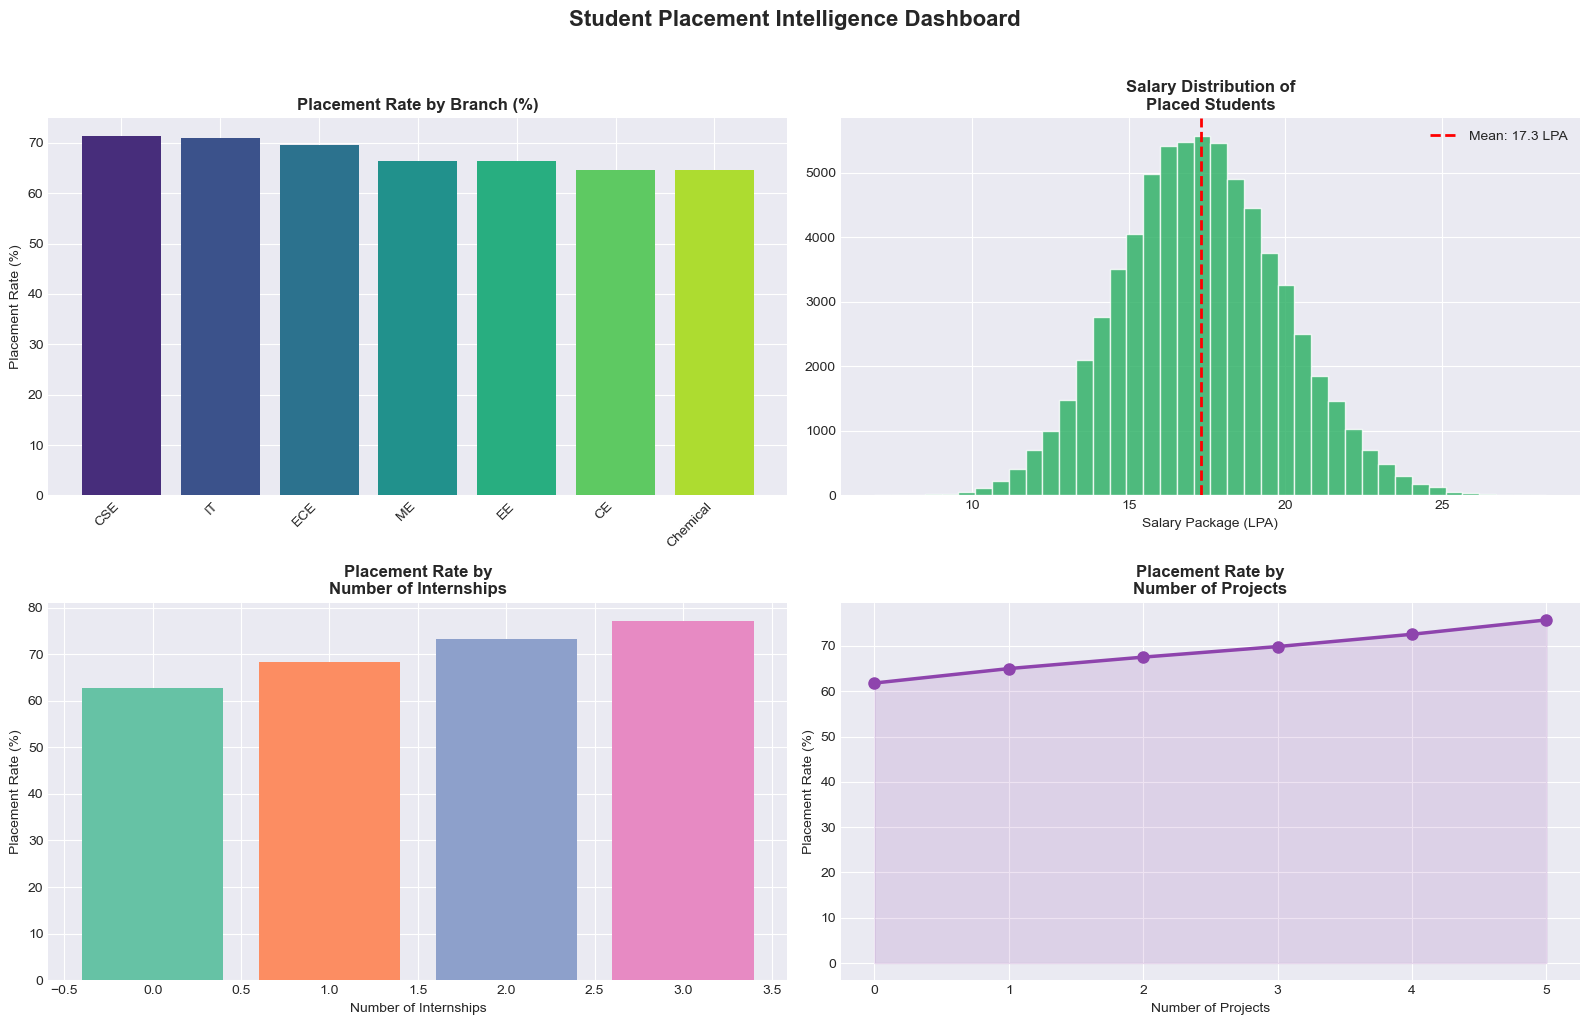

✅ Chart 11 saved!


In [6]:
fig = plt.figure(figsize=(16, 10))

# Chart A — Placement by Branch (top left)
ax1 = fig.add_subplot(2, 2, 1)
branch_place = placement.groupby('branch')['placement_status'].mean() * 100
branch_place = branch_place.sort_values(ascending=False).head(8)
bars = ax1.bar(branch_place.index, branch_place.values,
               color=sns.color_palette("viridis", len(branch_place)))
ax1.set_title('Placement Rate by Branch (%)',
              fontweight='bold')
ax1.set_xticklabels(branch_place.index, rotation=45, ha='right')
ax1.set_ylabel('Placement Rate (%)')

# Chart B — Salary distribution (top right)
ax2 = fig.add_subplot(2, 2, 2)
placed_salary = placement[placement['placement_status']==1]['salary_package_lpa']
ax2.hist(placed_salary, bins=40, color='#27ae60',
         edgecolor='white', alpha=0.8)
ax2.axvline(placed_salary.mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean: {placed_salary.mean():.1f} LPA')
ax2.set_title('Salary Distribution of\nPlaced Students',
              fontweight='bold')
ax2.set_xlabel('Salary Package (LPA)')
ax2.legend()

# Chart C — Internship impact (bottom left)
ax3 = fig.add_subplot(2, 2, 3)
intern_place = placement.groupby('internships')['placement_status'].mean() * 100
ax3.bar(intern_place.index, intern_place.values,
        color=sns.color_palette("Set2", len(intern_place)))
ax3.set_title('Placement Rate by\nNumber of Internships',
              fontweight='bold')
ax3.set_xlabel('Number of Internships')
ax3.set_ylabel('Placement Rate (%)')

# Chart D — Projects impact (bottom right)
ax4 = fig.add_subplot(2, 2, 4)
proj_place = placement.groupby('projects_count')['placement_status'].mean() * 100
ax4.plot(proj_place.index, proj_place.values,
         marker='o', color='#8e44ad', linewidth=2.5,
         markersize=8)
ax4.set_title('Placement Rate by\nNumber of Projects',
              fontweight='bold')
ax4.set_xlabel('Number of Projects')
ax4.set_ylabel('Placement Rate (%)')
ax4.fill_between(proj_place.index, proj_place.values,
                 alpha=0.15, color='#8e44ad')

plt.suptitle('Student Placement Intelligence Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/charts/chart11_placement_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved!")

In [7]:
print("=" * 60)
print("🎉 DAY 5 COMPLETE!")
print("=" * 60)
print("\n📊 Total Charts Created:")
print("   Day 3 Charts: chart1 to chart6")
print("   Day 5 Charts: chart7 to chart11")
print(f"\n✅ Total: 11 Professional Charts")
print("\n🔍 Key Advanced Insights:")

# Insight from yearly trend
best_year = layoffs.groupby('year')['total_laid_off'].sum().idxmax()
print(f"   📈 Highest layoff year: {int(best_year)}")

# Insight from placement
avg_salary = placement[placement['placement_status']==1]['salary_package_lpa'].mean()
print(f"   💰 Average placed student salary: {avg_salary:.2f} LPA")

# Internship insight
intern_rates = placement.groupby('internships')['placement_status'].mean() * 100
print(f"   🎓 Students with 2+ internships placement rate: {intern_rates.get(2, 0):.1f}%")

print("\n" + "=" * 60)
print("✅ Ready for Day 6 — Power BI Dashboard!")
print("=" * 60)

🎉 DAY 5 COMPLETE!

📊 Total Charts Created:
   Day 3 Charts: chart1 to chart6
   Day 5 Charts: chart7 to chart11

✅ Total: 11 Professional Charts

🔍 Key Advanced Insights:
   📈 Highest layoff year: 2023
   💰 Average placed student salary: 17.31 LPA
   🎓 Students with 2+ internships placement rate: 73.2%

✅ Ready for Day 6 — Power BI Dashboard!
